# Milestone 2: Multi-Step Funnel & Friction Analysis

## Business Question

Where are users dropping out of the five-stage product funnel, and does mobile experience significantly more friction than desktop?

## Funnel

Homepage → Product Page → Cart → Checkout → Payment

## Analytical Grain

After deduplication, each row represents one unique combination of:

`user_id + funnel_stage`

This prevents repeated clicks, refreshes, or tracking pings from inflating conversion metrics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Analysis environment initialized")

✅ Analysis environment initialized


In [3]:
n_users = 10_000

funnel_steps = [
    "1_Homepage",
    "2_Product_Page",
    "3_Cart",
    "4_Checkout",
    "5_Payment"
]

clickstream_records = []

for user_number in range(1, n_users + 1):
    user_id = f"USER_{user_number:05d}"
    device = "desktop" if np.random.random() < 0.50 else "mobile"

    # Every user enters through the homepage
    clickstream_records.append({
        "user_id": user_id,
        "device": device,
        "funnel_stage": "1_Homepage"
    })

    # Homepage → Product Page
    product_probability = 0.70 if device == "desktop" else 0.65

    if np.random.random() < product_probability:
        clickstream_records.append({
            "user_id": user_id,
            "device": device,
            "funnel_stage": "2_Product_Page"
        })

        # Product Page → Cart
        cart_probability = 0.55 if device == "desktop" else 0.45

        if np.random.random() < cart_probability:
            clickstream_records.append({
                "user_id": user_id,
                "device": device,
                "funnel_stage": "3_Cart"
            })

            # Cart → Checkout: intentional mobile friction
            checkout_probability = 0.60 if device == "desktop" else 0.30

            if np.random.random() < checkout_probability:
                clickstream_records.append({
                    "user_id": user_id,
                    "device": device,
                    "funnel_stage": "4_Checkout"
                })

                # Checkout → Payment
                payment_probability = 0.80 if device == "desktop" else 0.75

                if np.random.random() < payment_probability:
                    clickstream_records.append({
                        "user_id": user_id,
                        "device": device,
                        "funnel_stage": "5_Payment"
                    })

# Add duplicate tracking events to simulate refreshes/repeated pings
original_record_count = len(clickstream_records)

for _ in range(3_000):
    duplicate_index = np.random.randint(0, original_record_count)
    clickstream_records.append(clickstream_records[duplicate_index].copy())

df_clickstream = pd.DataFrame(clickstream_records)

print(f"Users entering funnel: {n_users:,}")
print(f"Raw clickstream rows: {len(df_clickstream):,}")
print(f"Injected duplicate rows: {len(df_clickstream) - original_record_count:,}")

df_clickstream.head()

Users entering funnel: 10,000
Raw clickstream rows: 26,061
Injected duplicate rows: 3,000


,user_id,device,funnel_stage
0,USER_00001,desktop,1_Homepage
1,USER_00002,mobile,1_Homepage
2,USER_00002,mobile,2_Product_Page
3,USER_00002,mobile,3_Cart
4,USER_00002,mobile,4_Checkout


In [4]:
duplicate_count = df_clickstream.duplicated(
    subset=["user_id", "funnel_stage"]
).sum()

df_dedup = (
    df_clickstream
    .drop_duplicates(subset=["user_id", "funnel_stage"])
    .reset_index(drop=True)
)

print(f"Duplicate user-stage rows detected: {duplicate_count:,}")
print(f"Rows before deduplication: {len(df_clickstream):,}")
print(f"Rows after deduplication:  {len(df_dedup):,}")

Duplicate user-stage rows detected: 3,000
Rows before deduplication: 26,061
Rows after deduplication:  23,061


In [5]:
funnel_summary = (
    df_dedup
    .groupby("funnel_stage")["user_id"]
    .nunique()
    .reindex(funnel_steps)
    .rename("unique_users")
    .reset_index()
)

previous_users = funnel_summary["unique_users"].shift(1)

funnel_summary["step_conversion_pct"] = (
    funnel_summary["unique_users"] / previous_users * 100
)

funnel_summary["drop_off_users"] = (
    previous_users - funnel_summary["unique_users"]
)

funnel_summary["drop_off_pct"] = (
    funnel_summary["drop_off_users"] / previous_users * 100
)

funnel_summary["cumulative_conversion_pct"] = (
    funnel_summary["unique_users"]
    / funnel_summary.loc[0, "unique_users"]
    * 100
)

# The homepage is the funnel entry point
funnel_summary.loc[0, "step_conversion_pct"] = 100
funnel_summary.loc[0, "drop_off_users"] = 0
funnel_summary.loc[0, "drop_off_pct"] = 0

funnel_summary.round(2)

,funnel_stage,unique_users,step_conversion_pct,drop_off_users,drop_off_pct,cumulative_conversion_pct
0,1_Homepage,10000,100.00,0.0,0.00,100.00
1,2_Product_Page,6731,67.31,3269.0,32.69,67.31
2,3_Cart,3396,50.45,3335.0,49.55,33.96
3,4_Checkout,1633,48.09,1763.0,51.91,16.33
4,5_Payment,1301,79.67,332.0,20.33,13.01


In [6]:
assert df_dedup.duplicated(
    subset=["user_id", "funnel_stage"]
).sum() == 0, "Duplicate user-stage combinations remain."

assert funnel_summary.loc[0, "unique_users"] == 10_000

assert funnel_summary["unique_users"].is_monotonic_decreasing, (
    "User counts must not increase further down the funnel."
)

assert np.allclose(
    funnel_summary["step_conversion_pct"]
    + funnel_summary["drop_off_pct"],
    100
), "Conversion and drop-off must total 100%."

print("✅ Deduplication and overall funnel validation passed")

✅ Deduplication and overall funnel validation passed


In [7]:
device_summary = (
    df_dedup
    .groupby(["device", "funnel_stage"])["user_id"]
    .nunique()
    .rename("unique_users")
    .reset_index()
)

device_summary["funnel_stage"] = pd.Categorical(
    device_summary["funnel_stage"],
    categories=funnel_steps,
    ordered=True
)

device_summary = (
    device_summary
    .sort_values(["device", "funnel_stage"])
    .reset_index(drop=True)
)

device_summary["previous_users"] = (
    device_summary
    .groupby("device", observed=True)["unique_users"]
    .shift(1)
)

device_summary["step_conversion_pct"] = (
    device_summary["unique_users"]
    / device_summary["previous_users"]
    * 100
)

device_summary["drop_off_pct"] = (
    100 - device_summary["step_conversion_pct"]
)

entry_stage = device_summary["funnel_stage"] == funnel_steps[0]

device_summary.loc[entry_stage, "step_conversion_pct"] = 100
device_summary.loc[entry_stage, "drop_off_pct"] = 0

device_summary.round(2)

,device,funnel_stage,unique_users,previous_users,step_conversion_pct,drop_off_pct
0,desktop,1_Homepage,5004,NaN,100.00,0.00
1,desktop,2_Product_Page,3487,5004.0,69.68,30.32
2,desktop,3_Cart,1966,3487.0,56.38,43.62
3,desktop,4_Checkout,1202,1966.0,61.14,38.86
4,desktop,5_Payment,964,1202.0,80.20,19.80
5,mobile,1_Homepage,4996,NaN,100.00,0.00
6,mobile,2_Product_Page,3244,4996.0,64.93,35.07
7,mobile,3_Cart,1430,3244.0,44.08,55.92
8,mobile,4_Checkout,431,1430.0,30.14,69.86
9,mobile,5_Payment,337,431.0,78.19,21.81


In [8]:
conversion_by_device = (
    device_summary
    .pivot(
        index="funnel_stage",
        columns="device",
        values="step_conversion_pct"
    )
    .reindex(funnel_steps)
)

conversion_by_device["desktop_minus_mobile_pp"] = (
    conversion_by_device["desktop"]
    - conversion_by_device["mobile"]
)

conversion_by_device.round(2)

device,desktop,mobile,desktop_minus_mobile_pp
funnel_stage,,,
1_Homepage,100.00,100.00,0.00
2_Product_Page,69.68,64.93,4.75
3_Cart,56.38,44.08,12.30
4_Checkout,61.14,30.14,31.00
5_Payment,80.20,78.19,2.01


In [9]:
device_user_counts = (
    device_summary
    .pivot(
        index="funnel_stage",
        columns="device",
        values="unique_users"
    )
    .reindex(funnel_steps)
)

assert np.array_equal(
    device_user_counts.sum(axis=1).to_numpy(),
    funnel_summary["unique_users"].to_numpy()
), "Desktop + mobile totals do not match the overall funnel."

largest_device_gap_stage = (
    conversion_by_device["desktop_minus_mobile_pp"].idxmax()
)

largest_device_gap = (
    conversion_by_device.loc[
        largest_device_gap_stage,
        "desktop_minus_mobile_pp"
    ]
)

print("✅ Device totals reconcile with the overall funnel")
print(f"Largest device gap: {largest_device_gap_stage}")
print(f"Desktop advantage: {largest_device_gap:.2f} percentage points")

✅ Device totals reconcile with the overall funnel
Largest device gap: 4_Checkout
Desktop advantage: 31.00 percentage points


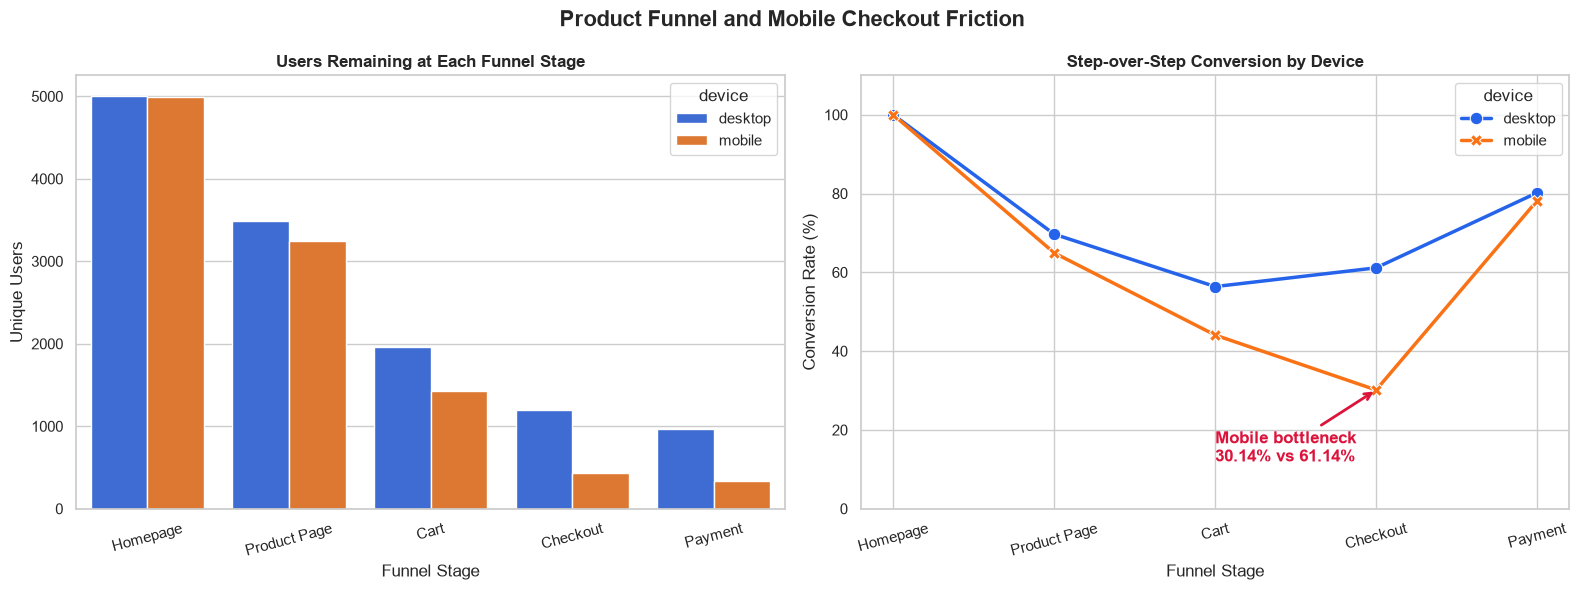

✅ Visualization saved to: d:\desktop\coding\Topfolio\A-B-Testing-Product-Experimentation-Analysis-M1\findings\figures\02_funnel_by_device.png


In [10]:
stage_labels = {
    "1_Homepage": "Homepage",
    "2_Product_Page": "Product Page",
    "3_Cart": "Cart",
    "4_Checkout": "Checkout",
    "5_Payment": "Payment"
}

plot_data = device_summary.copy()

plot_data["stage_label"] = (
    plot_data["funnel_stage"]
    .astype(str)
    .map(stage_labels)
)

stage_order = list(stage_labels.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Users remaining at each stage
sns.barplot(
    data=plot_data,
    x="stage_label",
    y="unique_users",
    hue="device",
    order=stage_order,
    palette={"desktop": "#2563EB", "mobile": "#F97316"},
    ax=axes[0]
)

axes[0].set_title(
    "Users Remaining at Each Funnel Stage",
    fontweight="bold"
)
axes[0].set_xlabel("Funnel Stage")
axes[0].set_ylabel("Unique Users")
axes[0].tick_params(axis="x", rotation=15)

# Chart 2: Step-over-step conversion
sns.lineplot(
    data=plot_data,
    x="stage_label",
    y="step_conversion_pct",
    hue="device",
    style="device",
    markers=True,
    dashes=False,
    sort=False,
    palette={"desktop": "#2563EB", "mobile": "#F97316"},
    linewidth=2.5,
    markersize=9,
    ax=axes[1]
)

axes[1].set_title(
    "Step-over-Step Conversion by Device",
    fontweight="bold"
)
axes[1].set_xlabel("Funnel Stage")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis="x", rotation=15)

# Highlight the principal mobile bottleneck
axes[1].annotate(
    "Mobile bottleneck\n30.14% vs 61.14%",
    xy=("Checkout", 30.14),
    xytext=("Cart", 12),
    arrowprops={
        "arrowstyle": "->",
        "color": "crimson",
        "linewidth": 2
    },
    color="crimson",
    fontweight="bold"
)

fig.suptitle(
    "Product Funnel and Mobile Checkout Friction",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# Work whether the notebook starts from the repo root or notebooks/
repo_root = Path.cwd()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

figure_directory = repo_root / "findings" / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

figure_path = figure_directory / "02_funnel_by_device.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Visualization saved to: {figure_path}")

In [11]:
checkout_metrics = conversion_by_device.loc["4_Checkout"]

print("Primary funnel diagnosis")
print("-" * 40)
print(f"Desktop conversion: {checkout_metrics['desktop']:.2f}%")
print(f"Mobile conversion:  {checkout_metrics['mobile']:.2f}%")
print(
    "Device gap: "
    f"{checkout_metrics['desktop_minus_mobile_pp']:.2f} percentage points"
)

Primary funnel diagnosis
----------------------------------------
Desktop conversion: 61.14%
Mobile conversion:  30.14%
Device gap: 31.00 percentage points
